In [1]:
import HeST as H
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import re
import cProfile
from numba import njit

from qetpy.utils import fft, ifft, fftfreq, rfftfreq

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
plt.rcParams['figure.dpi'] = 200


## Making a Valid Simulation

We're just going to import a pre-defined detector geometry.

We're also going to briefly plot the detector volume; feel free to comment this line out if you feel it takes to long/you aren't interested in it

(<Figure size 1280x960 with 1 Axes>, <Axes3D: >)

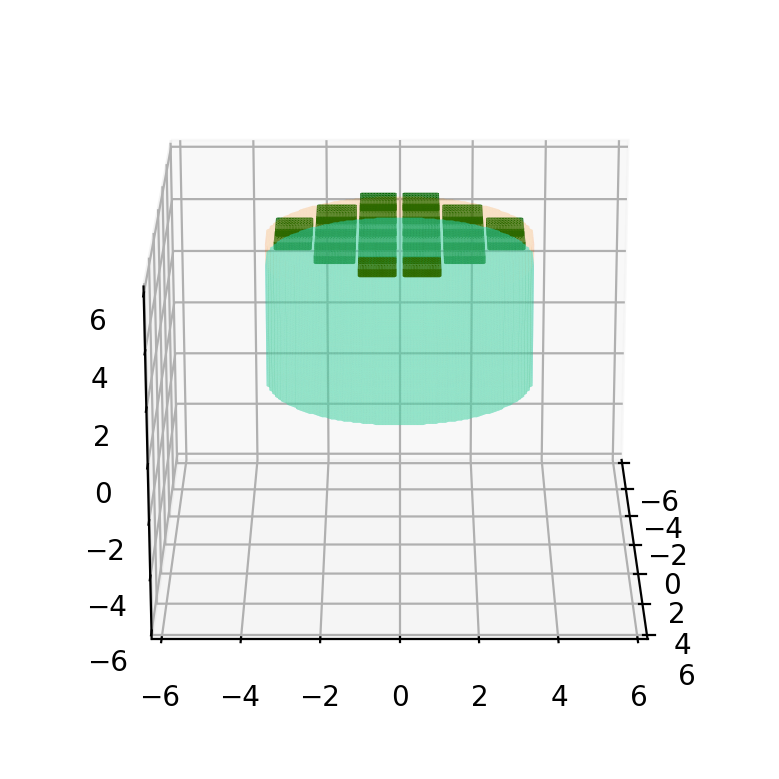

In [2]:
HeRALD_v1 = H.HeRALD_v1(fill_height=4.5)

HeRALD_v1.Plot_detector(xgrid = np.linspace(-4,4,100),
                        ygrid = np.linspace(-4,4,100),
                        zgrid = np.linspace(-1,5.5,100))

## Simple Evaporation Simulation

Simple Simulation. 1 QP with momentum 4.5 keV/c is generated and impinges on the vacuum interface with a fixed angle of incidence. 

Note that we've sent in a R+ roton, which tends to "refract" larger angles when evapoarting atoms. Feel free to change the momentum/angle; you'll discover that some momenta have "critical angles", past which evaporation will not occur. (In the object HeRALD_v1, we've elected not specify evaporation_eff, which would add in quantum mechanical probabilities for evaporation. In this simulation, evaporation occurs if it is classically permitted.)

Note that a Hest_Signal object is returned; this includes only energy deposits and timing information for each of the simulation's sensors.

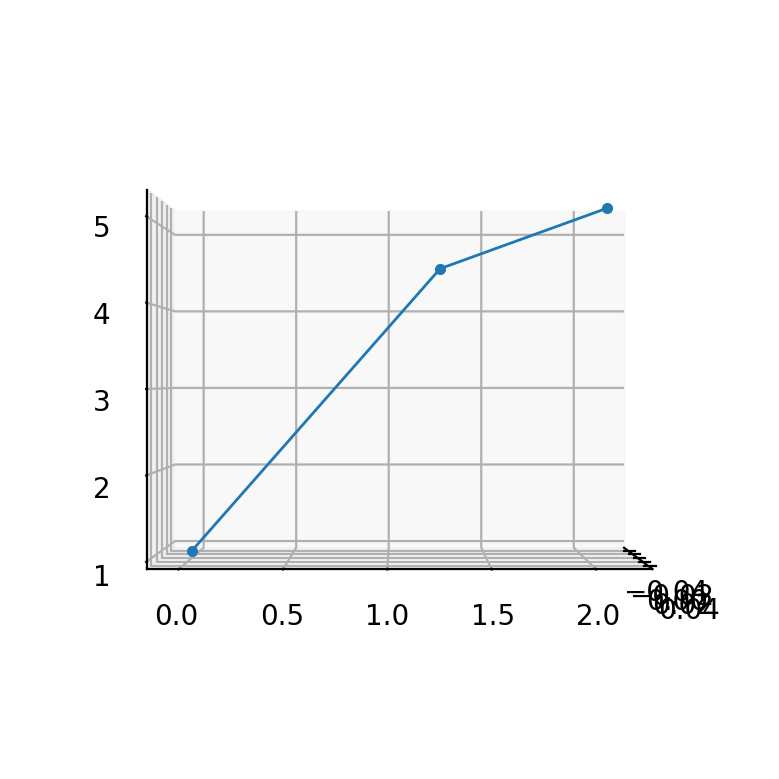

In [3]:
theta =20 #degreses
momentum = 4.5 #keV/c
signal = H.GetEvaporationSignal(HeRALD_v1, 1, 0.0, 0.0, 1.0,
                                useMap = False,
                                plot_3d = True, 
                                fixed_dir = (0, np.sin(theta * np.pi/180),np.cos(theta * np.pi/180)),
                                fixed_momentum = momentum,
                                debug = False,
                                verbose = False,
                                simulate_evap_probs=False)




## More Complex Evaporation Signal

More complex (and realistic) simulation. We neglect to specify a fixed direction/momentum, so the quasiparticles are emitted isotropically and with a Bose-Einstein distribution of momenta. Since we're adding random chance, it makes sense to simulate more than one; we're simulating 1000.

We also specify the debug flag which will return more detailed information that we would not be privy to in a realistic situation.

(We also run the same line without the plot3d flag and a lot more data quasiparticles for later use)

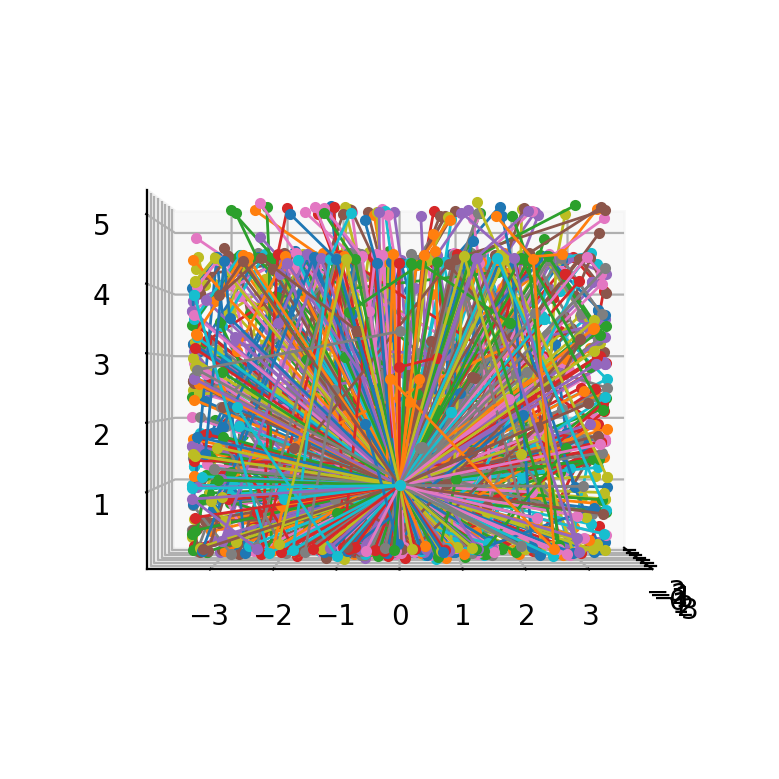

In [4]:
energyAtDeath, sensorIdsAll, evaporated, \
total_time, step_count, initial_momentum, paths = H.GetEvaporationSignal(HeRALD_v1, 1000, 0, 0, 1.0, 
                                                                         useMap = True,
                                                                         plot_3d = True, 
                                                                         debug = True,
                                                                         simulate_evap_probs=False)


energyAtDeath, sensorIdsAll, evaporated,\
total_time, step_count, initial_momentum, paths = H.GetEvaporationSignal(HeRALD_v1, 1000000, 0.0, 0.0, 2,
                                                                         useMap = False,
                                                                         plot_3d = False, 
                                                                         debug = True,
                                                                         simulate_evap_probs=False)


## Debug Analysis

When we specify the debug flag, we get a lot of information that we normally wouldn't be privy to in a real detector (e.g. original quasiparticle momentum, paths, etc.). Let's take advantage of this and make some interesting plots. There are plenty of interesting things to plot, so play around, but here are a few examples:

- Scatter plot of hit positions w/ Time delay as color axis
    - We can see that the outer sensors seem to get a higher proportion of later particles than do the sensors near the center axis

- Scatter plot of hit positions w/ deposited energy as color axis

- Delay Time vs. distance from the center axis
    - Tells a similar story to the first plot; our detectors may respond asynchronously, making triggering difficult
    - The quantization we see here is an artifact from the discrete step size that HeST uses. (default .05 cm). We can shrink this  at the cost of simulation time

- Delay Time vs. Quasiparticle momenta
    - Tells us which QP species arrive first. Roughly 1/velocity with corrections for the angle of evaporations (depending on Helium level). Note that we have a nonzero reflection probability, giving us a second/third band from quasiparticles that reflect once/twice

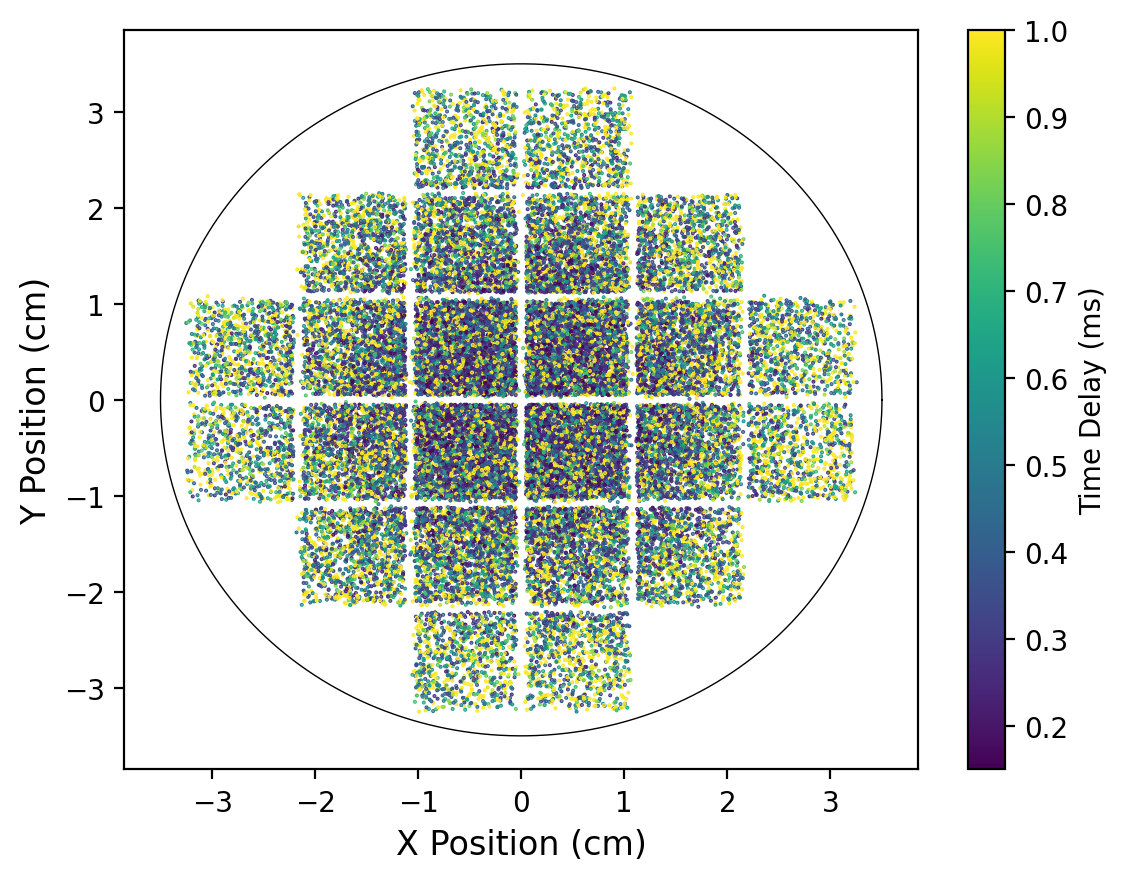

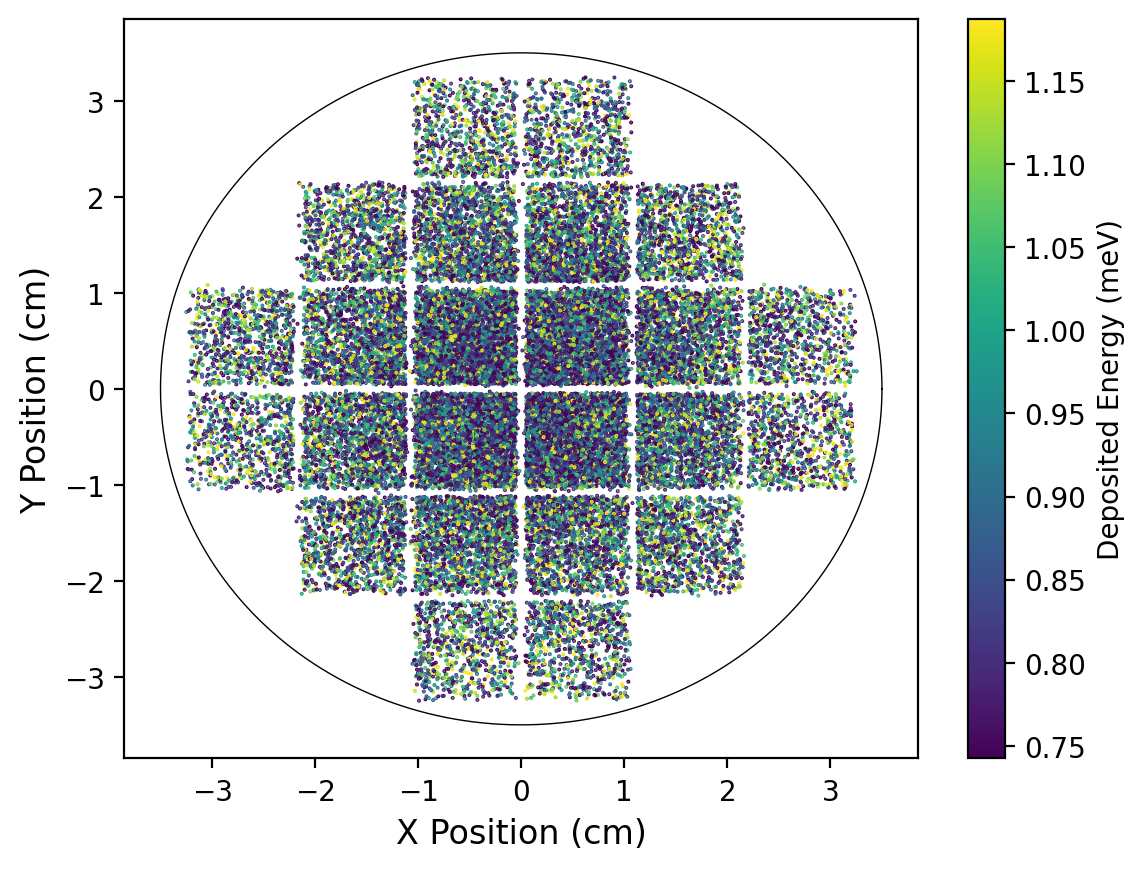

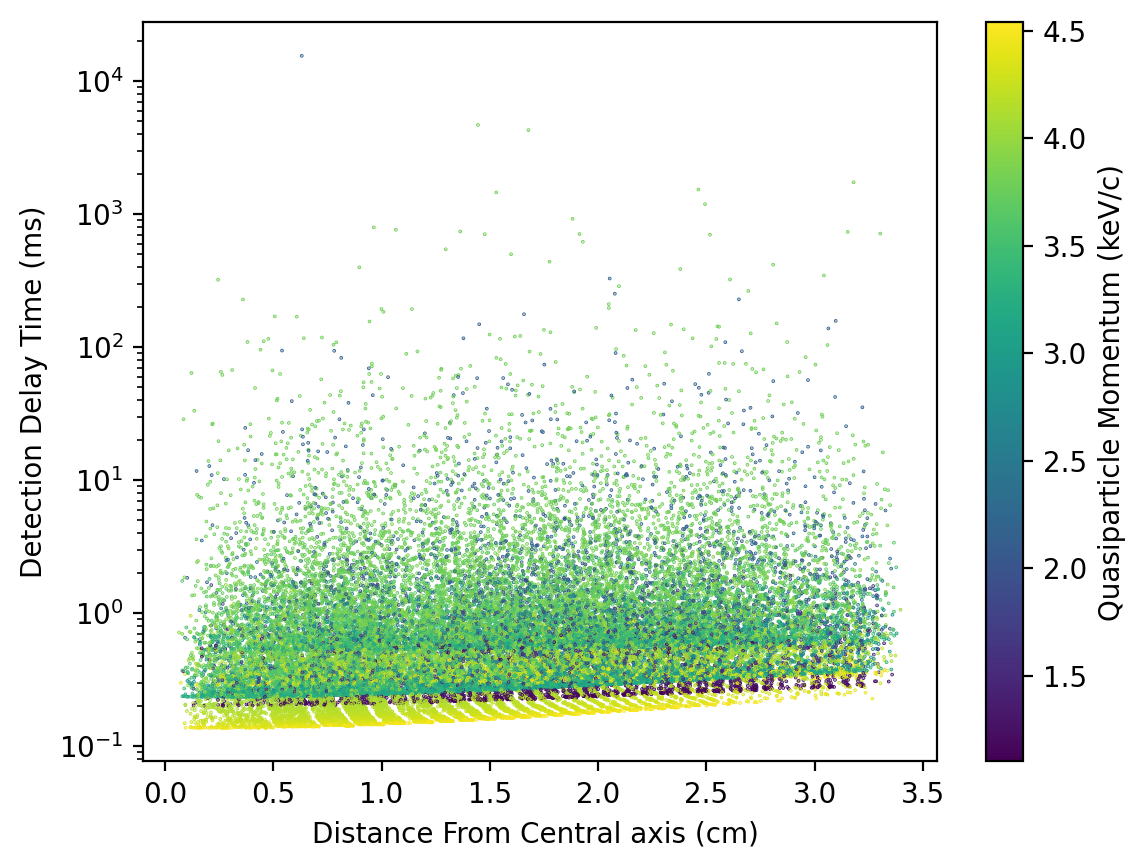

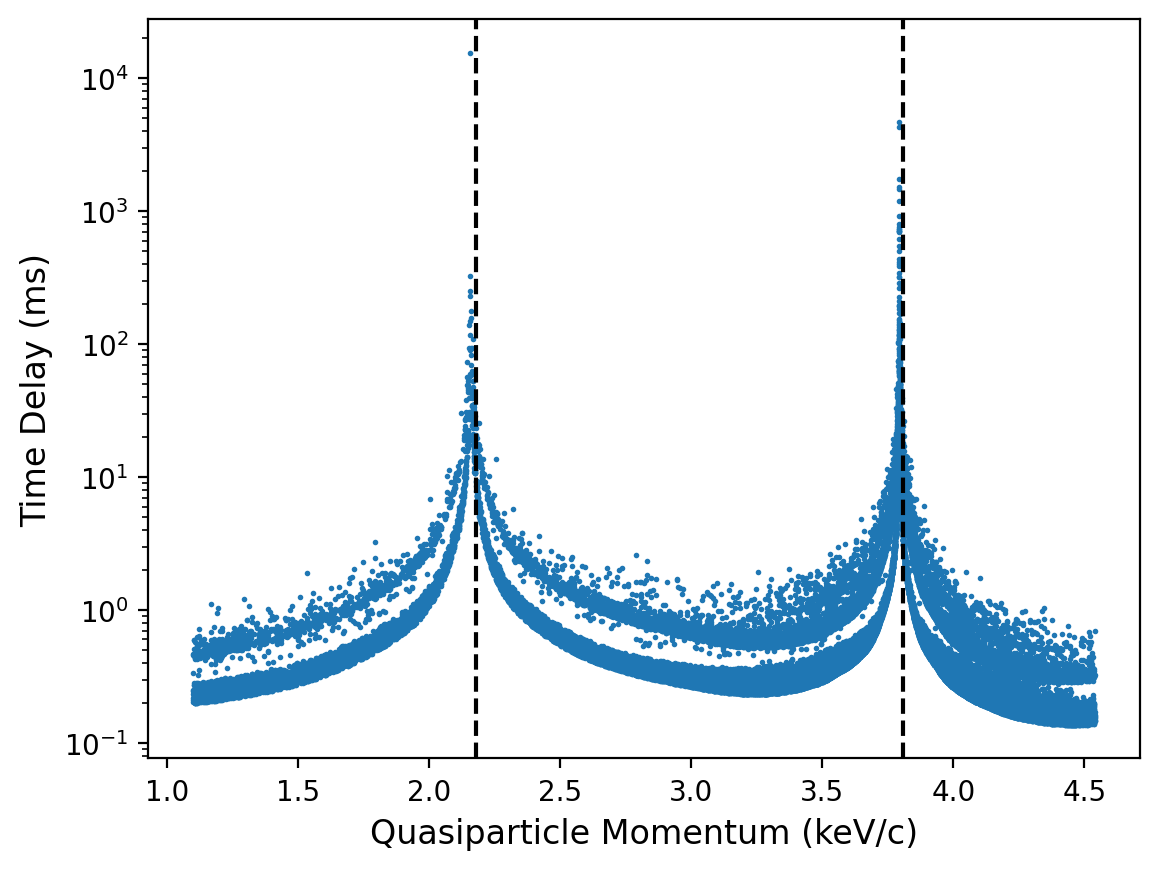

In [29]:
#sensorIdsAll contains information on undetected particles too; let's make a mask to weed out the undetected ones.
detected = sensorIdsAll > -.5

xs = paths[0]
ys = paths[1]
zs = paths[2]
xs.shape
xlist = []
ylist = []
momenta= []
times = []
channels = []
energies = []

# print(len(np.where(detected)[0]))
for i in np.where(detected)[0]:
    xlist.append(xs[i,step_count[i]])
    ylist.append(ys[i,step_count[i]])
    momenta.append(initial_momentum[i])
    times.append(total_time[i]/1000)
    channels.append(sensorIdsAll[i])
    energies.append(energyAtDeath[i]+ .000620) 
xlist = np.array(xlist)
ylist = np.array(ylist)
momenta = np.array(momenta)
times = np.array(times)
channels = np.array(channels)
energies = np.array(energies)

tdata = 2*np.pi*np.linspace(0,1, 1000)

fig, ax = plt.subplots()

sc = ax.scatter(xlist, ylist, s = .2, c = times, cmap='viridis', vmin=.15, vmax=1)
cbar = fig.colorbar(sc, ax=ax, label = 'Time Delay (ms)')
ax.plot(3.5*np.cos(tdata), 3.5*np.sin(tdata), linewidth = .5, color = 'k')

ax.set_xlabel('X Position (cm)', fontsize = 12)
ax.set_ylabel('Y Position (cm)', fontsize = 12)

fig, ax = plt.subplots()

sc = ax.scatter(xlist, ylist, s = .2, c = energies*1000, cmap='viridis')
cbar = fig.colorbar(sc, ax=ax, label = 'Deposited Energy (meV)')
tdata = 2*np.pi*np.linspace(0,1, 1000)
ax.plot(3.5*np.cos(tdata), 3.5*np.sin(tdata), linewidth = .5, color = 'k')

ax.set_xlabel('X Position (cm)', fontsize = 12)
ax.set_ylabel('Y Position (cm)', fontsize = 12)


rs = np.sqrt(xlist**2 + ylist**2)
fig, ax = plt.subplots()

sc = ax.scatter(rs, times, s = .1, c = momenta)
cbar = fig.colorbar(sc, ax=ax, label = 'Quasiparticle Momentum (keV/c)')

ax.set_yscale('log')

ax.set_xlabel('Distance From Central axis (cm) ')
ax.set_ylabel('Detection Delay Time (ms)')

fig, ax = plt.subplots()
ax.scatter(momenta, times, s = 1)
ax.set_xlabel('Quasiparticle Momentum (keV/c)', fontsize = 12)
ax.set_ylabel('Time Delay (ms)', fontsize = 12)
ax.axvline(2.180, color = 'k', ls = '--')
ax.axvline(3.809, color = 'k', ls = '--')
ax.set_yscale('log')


## Non-debug Simulations

We're gonna rerun our simulation with a couple of changes:
1. We're going to remove the debug flag and only take in information that we'd get out of a sensor (energy and timing)
2. We're going to run two simulations; one with reflection disabled and the other with the (diffuse) probability at ~30% (the number Doug estimated in the HeRALD v0.1 paper). 
3. We're going to originate our QPs off of the central axis.

It's clear that just 30% diffuse reflection makes a pretty significant difference in sigal size.

/home/wmatava/miniconda3/envs/py3_10/lib/python3.10/site-packages/HeST/core/Detection.py:1080: RuntimeWarning: invalid value encountered in sqrt
  sin = np.where( energy >= Vb, np.sqrt(2 * m *(energy - Vb))/np.abs(momentum *1000), 0)
/home/wmatava/miniconda3/envs/py3_10/lib/python3.10/site-packages/HeST/core/Detection.py:1081: RuntimeWarning: invalid value encountered in arcsin
  angle = np.where(np.abs(sin) < 1, np.arcsin(sin), np.arcsin(1))


17.79114758227958
44.53083496049625
[[0.         0.         0.35017414 0.45456823 0.         0.        ]
 [0.         0.54547134 0.87556423 0.94803914 0.88660892 0.        ]
 [0.26809931 0.87485068 1.38721022 2.43167337 2.32675638 1.22447694]
 [0.53722114 0.8741266  2.52314308 5.43770734 4.47359881 2.23861324]
 [0.         0.79046445 2.61688114 4.92951887 4.19022219 0.        ]
 [0.         0.         1.18317749 2.16266769 0.         0.        ]]


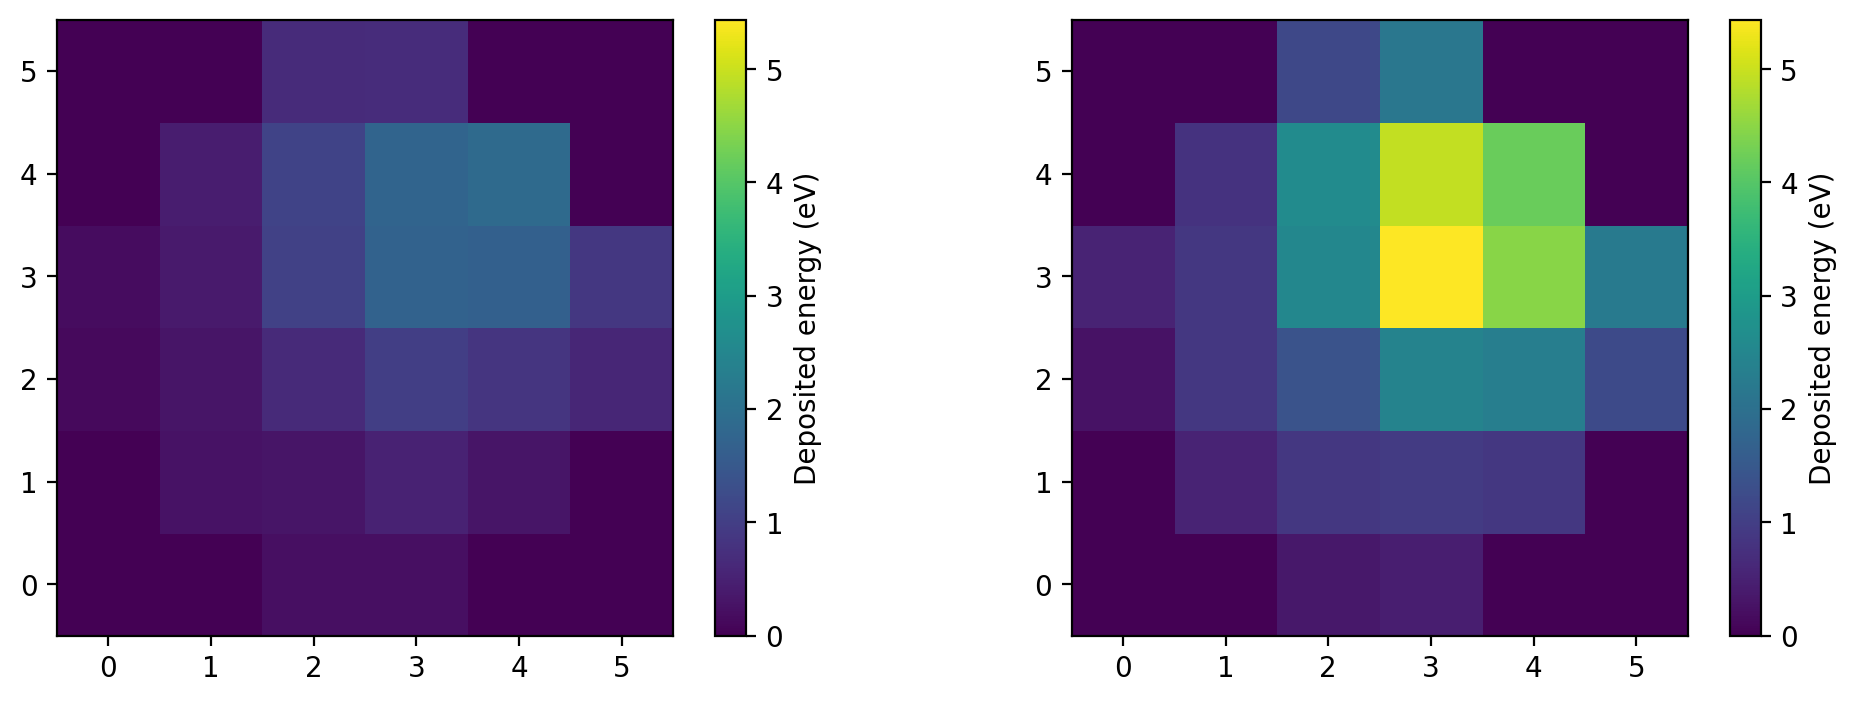

In [30]:
HeRALD_v1.set_QP_wall_reflection_prob(0.0)
Signal =  H.GetEvaporationSignal(HeRALD_v1, int(1e5), 1.0, 1.0, .5, 
                                   useMap = False,
                                   plot_3d = False, 
                                   debug = False,
                                   simulate_evap_probs=False)

HeRALD_v1.set_QP_wall_reflection_prob(0.3)
Signal2 =  H.GetEvaporationSignal(HeRALD_v1, int(1e5), 1.0, 1.0, .5, 
                                  useMap = False,
                                  plot_3d = False, 
                                  debug = False,
                                  simulate_evap_probs=False)


array = np.zeros((6,6))
array2 = np.zeros((6,6))
tot_sum = 0
tot_sum2 = 0

array_map = np.array([[0,0,1,1,0,0],
                      [0,1,1,1,1,0],
                      [1,1,1,1,1,1],
                      [1,1,1,1,1,1],
                      [0,1,1,1,1,0],
                      [0,0,1,1,0,0]])

sensor_locations = {}
sensor_id = 0
sqcm_pitch = 1.1
for i in range(array_map.shape[0]):
        for j in range(array_map.shape[1]):
            if array_map[i,j] > .5:
                x0, y0 = (i - 2.5)*sqcm_pitch, (j - 2.5)*sqcm_pitch, 
                # print(x0,y0)
                sensor_locations[str(sensor_id)] = (x0,y0)
                sensor_id += 1


for key in sensor_locations:
    x0,y0 = sensor_locations[key]
    x0 /= 1.1
    y0 /= 1.1
    x0 += 2.5
    y0 += 2.5
    array[int(y0), int(x0)] = np.sum(Signal.energies[int(key)])
    array2[int(y0), int(x0)] = np.sum(Signal2.energies[int(key)])
    tot_sum += np.sum(Signal.energies[int(key)])
    tot_sum2 += np.sum(Signal2.energies[int(key)])

print(tot_sum)
print(tot_sum2)

fig, ax = plt.subplots(ncols = 2, figsize = (12,4))

im = ax[0].imshow(array, origin='lower', vmin = 0, vmax = np.max(array2))
im2 = ax[1].imshow(array2, origin='lower', vmin = 0, vmax = np.max(array2))


fig.colorbar(im, label = 'Deposited energy (eV)')
fig.colorbar(im2, label = 'Deposited energy (eV)')

# xproj = np.sum(array,axis = 0)
# yproj = np.sum(array,axis = 1)

print(array2)


## Speed Tests

In [ ]:
cProfile.run('Signal = H.GetEvaporationSignal(HeRALD_v1, 100000, 1.1, 0, .25, useMap = False, plot_3d = False,debug = False)')
#1e5 in 2 seconds -> 1e7 in 200? Doesn't scale...

         16710 function calls (16392 primitive calls) in 1.748 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(any)
       48    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(append)
      350    0.000    0.000    0.073    0.000 <__array_function__ internals>:177(argmax)
       30    0.000    0.000    0.001    0.000 <__array_function__ internals>:177(broadcast_arrays)
       48    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(concatenate)
        1    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(copy)
      295    0.000    0.000    0.017    0.000 <__array_function__ internals>:177(copyto)
        1    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(cumsum)
       54    0.000    0.000    0.000    0.000 <__array_function__ internals>:177(empty_like)
       13  